# 1. Preproccessing


#### Imports

In [397]:
# import from google 
# from google.colab import drive
# drive.mount('/content/drive')

In [398]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
from sklearn.cluster import KMeans



In [399]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from xgboost import XGBClassifier


In [400]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score, precision_score
)

####Column Name

In [401]:
LABEL_COL = "Label"          # target column name after stripping spaces

# Features to DROP (identifiers / leakage / near-zero variance)
DROP_COLS = [
    "Flow ID", "Source IP", "Destination IP","Timestamp",
    "Fwd Header Length.1",          # duplicate column present in some files
]

#### Load All CSV Files

In [402]:
def load_dataset(data_dir: str) -> pd.DataFrame:
    """
    Load all CSV files from the CIC-IDS2017 directory.
    Expected files: Monday, Tuesday, Wednesday, Thursday, Friday CSVs.
    """
    csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {data_dir}")

    frames = []
    for f in csv_files:
        print(f"  Loading: {os.path.basename(f)}")
        df = pd.read_csv(f, low_memory=False)
        df.columns = df.columns.str.strip()   # remove leading/trailing spaces
        frames.append(df)

    combined = pd.concat(frames, ignore_index=True)
    print(f"\n Total records loaded: {len(combined):,}")
    print(f"  Columns: {len(combined.columns)}")
    return combined

#### Cleaning

In [403]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    print("\n[Clean] Starting shape:", df.shape)

    # Drop identifier / leakage columns if present
    drop = [c for c in DROP_COLS if c in df.columns]
    df = df.drop(columns=drop)

    # Strip label strings
    df[LABEL_COL] = df[LABEL_COL].str.strip()

    # Replace inf with NaN, then drop rows with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    before = len(df)
    df.dropna(inplace=True)
    print(f"  Dropped {before - len(df):,} rows with NaN/Inf")

    # Remove duplicate rows
    before = len(df)
    df.drop_duplicates(inplace=True)
    print(f"  Dropped {before - len(df):,} duplicate rows")

    print("[Clean] Final shape:", df.shape)
    return df

#### Encoding Labels

In [404]:
def encode_labels(df: pd.DataFrame, binary: bool = True):
    """
    binary=True  → BENIGN=0, everything else=1  (anomaly detection style)
    binary=False → multi-class encoding
    Returns (df, label_encoder or None)
    """
    if binary:
        df[LABEL_COL] = (df[LABEL_COL] != "BENIGN").astype(int)
        print(f"\n[Labels] Binary — BENIGN=0, ATTACK=1")
        print(df[LABEL_COL].value_counts())
        return df, None
    else:
        le = LabelEncoder()
        df[LABEL_COL] = le.fit_transform(df[LABEL_COL])
        print(f"\n[Labels] Multi-class ({len(le.classes_)} classes):")
        for i, c in enumerate(le.classes_):
            print(f"  {i}: {c}")
        return df, le


#### Split & Scale

In [405]:
def split_and_scale(df: pd.DataFrame, test_size: float = 0.2, random_state: int = 42):
    """
    Returns X_train, X_test, y_train, y_test (scaled), plus the fitted scaler.
    """
    X = df.drop(columns=[LABEL_COL]).values.astype(np.float32)
    y = df[LABEL_COL].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"\n[Split] Train: {X_train.shape}  |  Test: {X_test.shape}")
    print(f"  Train attack rate: {y_train.mean():.3f}")
    print(f"  Test  attack rate: {y_test.mean():.3f}")

    return X_train, X_test, y_train, y_test, scaler


####Save Artifacts

In [406]:
def save_artifacts(X_train, X_test, y_train, y_test, scaler, out_dir="./artifacts"):
    os.makedirs(out_dir, exist_ok=True)
    np.save(f"{out_dir}/X_train.npy", X_train)
    np.save(f"{out_dir}/X_test.npy",  X_test)
    np.save(f"{out_dir}/y_train.npy", y_train)
    np.save(f"{out_dir}/y_test.npy",  y_test)
    joblib.dump(scaler, f"{out_dir}/scaler.pkl")
    print(f"\n Artifacts saved to ./{out_dir}/")


#### Main

In [407]:
if __name__ == "__main__":
    DATA_DIR = "./MachineLearningCVE"          # ← point this at your CIC-IDS2017 CSV folder

    df = load_dataset(DATA_DIR)
    df.columns.tolist()
    df = clean(df)
    df, le = encode_labels(df, binary=True)   # change to False for multi-class
    X_train, X_test, y_train, y_test, scaler = split_and_scale(df)
    save_artifacts(X_train, X_test, y_train, y_test, scaler)






  Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
  Loading: Monday-WorkingHours.pcap_ISCX.csv
  Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Loading: Tuesday-WorkingHours.pcap_ISCX.csv
  Loading: Wednesday-workingHours.pcap_ISCX.csv

 Total records loaded: 2,830,743
  Columns: 79

[Clean] Starting shape: (2830743, 79)
  Dropped 2,867 rows with NaN/Inf
  Dropped 307,078 duplicate rows
[Clean] Final shape: (2520798, 78)

[Labels] Binary — BENIGN=0, ATTACK=1
Label
0    2095057
1     425741
Name: count, dtype: int64

[Split] Train: (2016638, 77)  |  Test: (504160, 77)
  Train attack rate: 0.169
  Test  attack rate: 0.169

 Artifacts saved to ././artifacts/


#### Verification

In [408]:
print("=" * 50)
print("PREPROCESSING VERIFICATION")
print("=" * 50)

# 1. Shape
print(f"\n Dataset shape: {X_train.shape} train | {X_test.shape} test")

# 2. Label balance
print(f"\n Label distribution:")
print(f"   Train — BENIGN: {(y_train==0).sum():,}  ATTACK: {(y_train==1).sum():,}")
print(f"   Test  — BENIGN: {(y_test==0).sum():,}   ATTACK: {(y_test==1).sum():,}")

# 3. Check no NaNs or Infs survived
import numpy as np
print(f"\n NaN in X_train:  {np.isnan(X_train).sum()}")
print(f" Inf in X_train:  {np.isinf(X_train).sum()}")

# 4. Scaling sanity check (should be close to mean≈0, std≈1)
print(f"\n Scaling check (should be ~0 mean, ~1 std):")
print(f"   Mean: {X_train.mean():.4f}")
print(f"   Std:  {X_train.std():.4f}")

# 5. Feature count
print(f"\n Number of features: {X_train.shape[1]}")

print("\n" + "=" * 50)

PREPROCESSING VERIFICATION

 Dataset shape: (2016638, 77) train | (504160, 77) test

 Label distribution:
   Train — BENIGN: 1,676,045  ATTACK: 340,593
   Test  — BENIGN: 419,012   ATTACK: 85,148

 NaN in X_train:  0
 Inf in X_train:  0

 Scaling check (should be ~0 mean, ~1 std):
   Mean: 0.0000
   Std:  0.9466

 Number of features: 77



# 2. Feature Selection  

#### Load Sample

In [409]:
def load_sample(csv_path: str, n: int = 50_000) -> pd.DataFrame:
    """Load a sample of rows from one CSV file for analysis."""
    df = pd.read_csv(csv_path, low_memory=False, nrows=n)
    df.columns = df.columns.str.strip()
    df["Label"] = df["Label"].str.strip()

    # Drop non-feature columns
    drop = ["Flow ID", "Source IP", "Destination IP",
             "Timestamp",
            "Fwd Header Length.1"]
    df.drop(columns=[c for c in drop if c in df.columns], inplace=True)

    # Binary encode label
    df["Label"] = (df["Label"] != "BENIGN").astype(int)

    # Drop inf/NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    return df

#### Scoring

In [410]:
def score_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns a DataFrame ranking every feature on 5 criteria.
    Each criterion scored 0–1, final score is weighted average.
    """
    features = [c for c in df.columns if c != "Label"]
    X = df[features]
    y = df["Label"]

    results = []

    # ── Train a quick RF to get feature importances ──
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    rf = RandomForestClassifier(n_estimators=50, max_depth=10,
                                n_jobs=-1, random_state=42)
    rf.fit(X_scaled, y)
    importances = rf.feature_importances_
    importances_norm = importances / (importances.max() + 1e-9)

    # ── Correlation matrix (for coupling score) ──
    corr_matrix = X.corr().abs()

    for i, feat in enumerate(features):
        col = X[feat]
        benign_vals  = col[y == 0]
        attack_vals  = col[y == 1]

        # 1. VARIANCE SCORE — higher std = more natural cover for noise
        std = col.std()
        # var_score = min(std / (col.abs().mean() + 1e-9), 1.0)
        var_score = min(col.std() / (col.abs().mean() + 1e-9), 1.0)

        # 2. CONTINUITY SCORE — penalise binary/low-cardinality features
        n_unique = col.nunique()
        cont_score = min(n_unique / 50, 1.0)   # 50+ unique values → score of 1
        # cont_score = min(n_unique / 500, 1.0)

        # 3. IMPORTANCE SCORE — model actually uses this feature
        imp_score = float(importances_norm[i])

        # 4. LOW COUPLING SCORE — not tightly correlated with other features
        #    Take mean absolute correlation with all OTHER features
        other_corrs = corr_matrix[feat].drop(feat)
        mean_corr = other_corrs.mean()
        coupling_score = 1.0 - mean_corr   # low correlation = high score

        # 5. DISTRIBUTION OVERLAP SCORE — benign & attack values overlap
        #    Use overlap of the interquartile ranges as a proxy
        b_q1, b_q3 = benign_vals.quantile(0.25), benign_vals.quantile(0.75)
        a_q1, a_q3 = attack_vals.quantile(0.25), attack_vals.quantile(0.75)
        overlap_lo = max(b_q1, a_q1)
        overlap_hi = min(b_q3, a_q3)
        overlap = max(0, overlap_hi - overlap_lo)
        total_range = max(b_q3, a_q3) - min(b_q1, a_q1) + 1e-9
        overlap_score = overlap / total_range

        # ── WEIGHTED FINAL SCORE ──
        # Importance weighted highest for our use case
        final = (
            0.20 * var_score +
            0.35 * imp_score+
            0.25 * coupling_score +
            0.20 * overlap_score
        )
        final = min(final, 1.0)

        results.append({
            "feature":          feat,
            "variance_score":   round(var_score,      3),
            "importance_score": round(imp_score,      5),
            "low_coupling":     round(coupling_score, 3),
            "overlap_score":    round(overlap_score,  3),
            "final_score":      round(final,          3),
        })

    scored = pd.DataFrame(results).sort_values("final_score", ascending=False)
    scored["rank"] = range(1, len(scored) + 1)
    return scored


#### Print Results

In [411]:
def print_results(scored: pd.DataFrame, top_n: int = 20):
    print("\n" + "="*75)
    print("  FEATURE PERTURBATION CANDIDACY RANKING")
    print("="*75)
    print(f"{'Rank':<5} {'Feature':<35} {'Var':>5}  "
          f"{'Imp':>7} {'Coup':>5} {'Ovlp':>5} {'SCORE':>7}")
    print("-"*75)

    for _, row in scored.head(top_n).iterrows():
        print(f"  {int(row['rank']):<4} {row['feature']:<35} "
              f"{row['variance_score']:>5.2f} "
              f"{row['importance_score']:>7.4f} "
              f"{row['low_coupling']:>5.2f} "
              f"{row['overlap_score']:>5.2f} "
              f"{row['final_score']:>7.3f}")



#### Visualize

In [412]:
def plot_candidacy(scored: pd.DataFrame, out_dir: str = "results"):
    os.makedirs(out_dir, exist_ok=True)
    top20 = scored.head(20)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle("Feature Perturbation Candidacy Analysis", fontsize=14, fontweight="bold")

    # ── Left: horizontal bar chart of final scores ──
    colors = ["#e74c3c" if i < 10 else "#95a5a6" for i in range(len(top20))]
    axes[0].barh(top20["feature"][::-1], top20["final_score"][::-1],
                 color=colors[::-1], edgecolor="black", linewidth=0.5)
    axes[0].set_xlabel("Candidacy Score")
    axes[0].set_title("Top 20 Features by Perturbation Score\n(red = recommended top 10)")
    axes[0].axvline(x=top20.iloc[9]["final_score"], color="red",
                    linestyle="--", linewidth=1, label="Top 10 cutoff")
    axes[0].legend()

    # ── Right: heatmap of score breakdown for top 15 ──
    top15 = scored.head(15).set_index("feature")
    heat_cols = ["variance_score", "continuity_score",
                 "low_coupling", "overlap_score"]
    sns.heatmap(top15[heat_cols], annot=True, fmt=".2f", cmap="YlOrRd",
                linewidths=0.5, ax=axes[1])
    axes[1].set_title("Score Breakdown — Top 15 Features")
    axes[1].set_xticklabels(["Variance", "Continuity", "Low Coupling", "Overlap"],
                             rotation=20, ha="right")

    plt.tight_layout()
    path = f"{out_dir}/feature_candidacy.png"
    plt.savefig(path, dpi=150)
    print(f"\n Plot saved: {path}")


#### Main

Loading sample data ...
  Loaded 49,952 rows, 77 features

Scoring features (training quick RF) ...

  FEATURE PERTURBATION CANDIDACY RANKING
Rank  Feature                               Var      Imp  Coup  Ovlp   SCORE
---------------------------------------------------------------------------
  1    Bwd IAT Max                          1.00  1.0000  0.76  0.06   0.752
  2    Bwd IAT Mean                         1.00  0.7771  0.78  0.01   0.669
  3    Fwd IAT Min                          1.00  0.7542  0.81  0.00   0.666
  4    Init_Win_bytes_backward              1.00  0.2011  0.96  0.78   0.665
  5    Bwd IAT Std                          1.00  0.7287  0.83  0.00   0.663
  6    Idle Min                             1.00  0.1998  0.78  0.87   0.641
  7    Fwd Packet Length Std                1.00  0.1165  0.83  0.92   0.634
  8    Init_Win_bytes_forward               1.00  0.4165  0.86  0.28   0.618
  9    Active Std                           1.00  0.5248  0.89  0.00   0.605
  10   Flow 

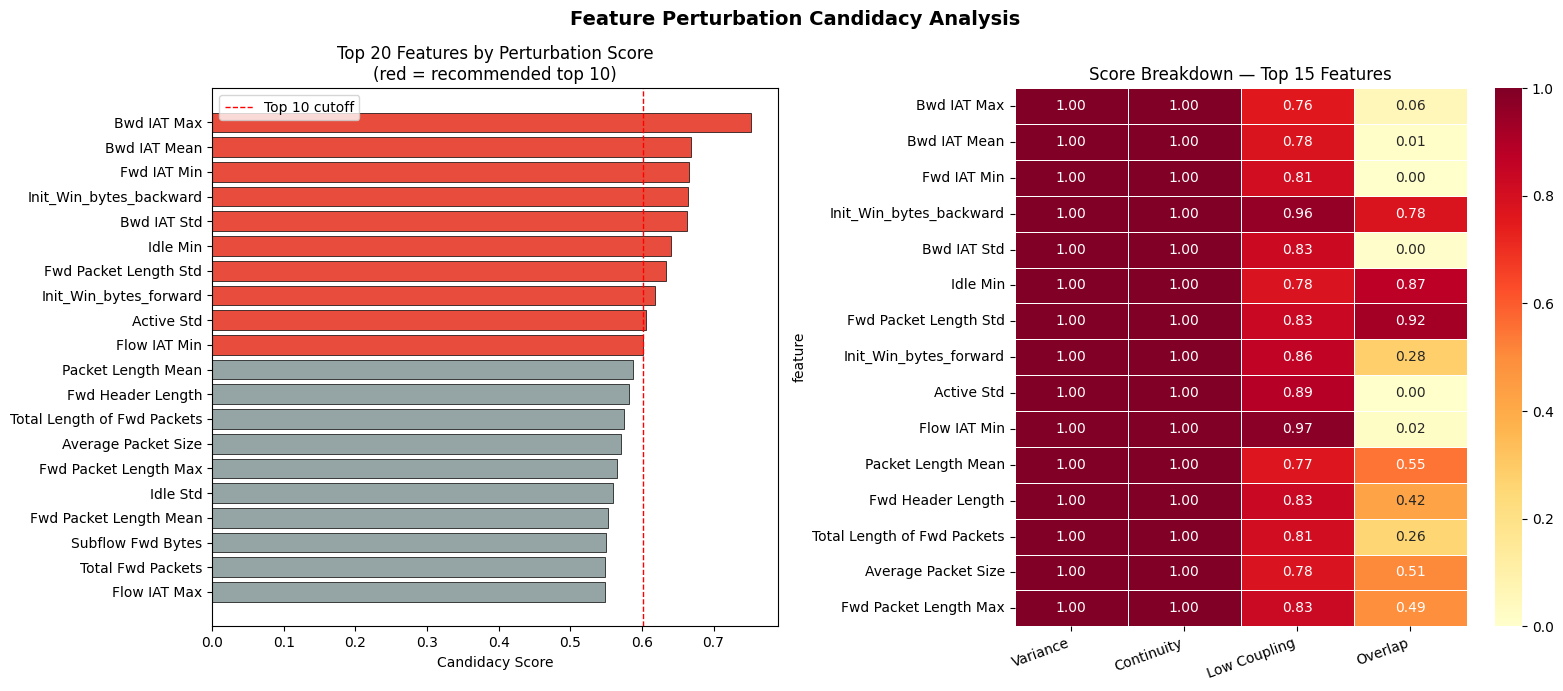

In [413]:
if __name__ == "__main__":
    CSV_PATH = "./MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv"



    print("Loading sample data ...")
    df = load_sample(CSV_PATH, n=50_000)
    print(f"  Loaded {len(df):,} rows, {len(df.columns)-1} features")

    print("\nScoring features (training quick RF) ...")
    scored = score_features(df)

    # Filter out non-continuous features before ranking
    scored_filtered["rank"] = range(1, len(scored_filtered) + 1)
    print_results(scored_filtered, top_n=20)

    plot_candidacy(scored_filtered)

    # Save full ranking to CSV
    scored_filtered.to_csv("results/feature_candidacy_scores.csv", index=False)
    print("\n Full ranking saved: results/feature_candidacy_scores.csv")

# 3. Poisoning

#### Feature Index Map

In [414]:
# ─────────────────────────────────────────────────────────────────
# FEATURE INDEX MAP (binary-encoded CIC-IDS2017, after dropping IDs)
# These are the "small attribute" targets described in your project.
# Indices here reference the column order AFTER preprocessing.
# Update if your drop list differs.
# ─────────────────────────────────────────────────────────────────
# SMALL_ATTRIBUTE_INDICES = {
#     "Flow Duration":            0,
#     "Total Fwd Packets":        1,
#     "Total Backward Packets":   2,
#     "Fwd Packet Length Mean":   7,
#     "Bwd Packet Length Mean":   11,
#     "Flow IAT Mean":            14,
#     "Fwd IAT Mean":             18,
#     "Packet Length Mean":       30,
#     "Average Packet Size":      34,
# }

# SMALL_ATTRIBUTE_INDICES = {
#     "Bwd IAT Max":               27,
#     "Init_Win_bytes_backward":   65,
#     "Idle Min":                  75,
#     "Flow IAT Min":              18,
#     "Fwd Packet Length Std":      8,
#     "Fwd Header Length":         33,
#     "Bwd IAT Std":               26,
#     "Average Packet Size":       51,
#     "Init_Win_bytes_forward":    64,
#     "Packet Length Mean":        39,
# }

SMALL_ATTRIBUTE_INDICES = {
    "Bwd IAT Max": 28,
    "Bwd IAT Mean": 26,
    "Fwd IAT Min": 24,
    "Init_Win_bytes_backward": 66,
    "Bwd IAT Std": 27,
    "Idle Min": 76,
    "Fwd Packet Length Std": 9,
    "Init_Win_bytes_forward": 65,
    "ACK Flag Count": 47,
    "PSH Flag Count": 46,
}

In [415]:
# ── Resolve SMALL_ATTRIBUTE_INDICES from scored results ──
TOP_N = 10  # change to however many you want

CSV_PATH = "./MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv"

df_cols = pd.read_csv(CSV_PATH, nrows=1, low_memory=False)
df_cols.columns = df_cols.columns.str.strip()

drop = ["Flow ID", "Source IP", "Destination IP", "Timestamp",
        "Fwd Header Length.1", "Label"]
df_cols.drop(columns=[c for c in drop if c in df_cols.columns], inplace=True)

feature_list = list(df_cols.columns)

# Pull top N features from your scored results
top_features = scored.head(TOP_N)["feature"].tolist()

SMALL_ATTRIBUTE_INDICES = {}
missing = []

for feat in top_features:
    if feat in feature_list:
        SMALL_ATTRIBUTE_INDICES[feat] = feature_list.index(feat)
    else:
        missing.append(feat)

# Print ready-to-paste dict
print("SMALL_ATTRIBUTE_INDICES = {")
for feat, idx in SMALL_ATTRIBUTE_INDICES.items():
    print(f'    "{feat}": {idx},')
print("}")

if missing:
    print(f"\n⚠️  Not found in columns: {missing}")

SMALL_ATTRIBUTE_INDICES = {
    "Bwd IAT Max": 28,
    "Bwd IAT Mean": 26,
    "Fwd IAT Min": 24,
    "Init_Win_bytes_backward": 66,
    "Bwd IAT Std": 27,
    "Idle Min": 76,
    "Fwd Packet Length Std": 9,
    "Init_Win_bytes_forward": 65,
    "ACK Flag Count": 47,
    "PSH Flag Count": 46,
}


#### Label Flipping Attack

In [416]:
def label_flip_attack(
    X_train: np.ndarray,
    y_train: np.ndarray,
    poison_rate: float = 0.05,
    random_state: int = 42,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Randomly flips `poison_rate` fraction of ATTACK (1) samples → BENIGN (0).

    Returns
    -------
    X_poisoned : same features, unchanged
    y_poisoned : labels with flipped subset
    poison_mask : boolean array — True where label was flipped
    """
    rng = np.random.default_rng(random_state)

    attack_indices = np.where(y_train == 1)[0]
    n_poison = int(len(attack_indices) * poison_rate)

    chosen = rng.choice(attack_indices, size=n_poison, replace=False)

    y_poisoned = y_train.copy()
    y_poisoned[chosen] = 0          # flip attack → benign

    poison_mask = np.zeros(len(y_train), dtype=bool)
    poison_mask[chosen] = True

    print(f"\n[Label Flip] poison_rate={poison_rate:.0%}")
    print(f"  Attack samples in train : {len(attack_indices):,}")
    print(f"  Labels flipped          : {n_poison:,}")
    print(f"  New attack rate         : {y_poisoned.mean():.4f}  "
          f"(was {y_train.mean():.4f})")

    return X_train.copy(), y_poisoned, poison_mask



#### Feature Perturbation

In [417]:
def feature_perturbation_attack(
    X_train: np.ndarray,
    y_train: np.ndarray,
    feature_indices: list[int] | None = None,
    noise_std: float = 0.05,
    poison_rate: float = 0.20,
    random_state: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Adds small Gaussian noise to selected features of a subset of attack samples.
    Because features are StandardScaler-normalized, noise_std=0.05 means
    ~5% of one standard deviation — visually imperceptible but enough to
    shift the decision boundary.

    Parameters
    feature_indices : list of column indices to perturb (defaults to SMALL_ATTRIBUTE_INDICES)
    noise_std       : Gaussian noise magnitude (relative to scaled feature space)
    poison_rate     : fraction of attack samples to perturb

    Returns
    X_poisoned : feature matrix with perturbations applied
    poison_mask : boolean array
    """
    if feature_indices is None:
        feature_indices = list(SMALL_ATTRIBUTE_INDICES.values())

    rng = np.random.default_rng(random_state)

    attack_indices = np.where(y_train == 1)[0]
    n_poison = int(len(attack_indices) * poison_rate)
    chosen = rng.choice(attack_indices, size=n_poison, replace=False)

    X_poisoned = X_train.copy()
    noise = rng.normal(loc=0.0, scale=noise_std,
                       size=(n_poison, len(feature_indices)))
    X_poisoned[np.ix_(chosen, feature_indices)] += noise

    poison_mask = np.zeros(len(y_train), dtype=bool)
    poison_mask[chosen] = True

    print(f"\n[Feature Perturbation] poison_rate={poison_rate:.0%}  noise_std={noise_std}")
    print(f"  Features perturbed : {len(feature_indices)} "
          f"({list(SMALL_ATTRIBUTE_INDICES.keys())[:3]} ...)")
    print(f"  Samples modified   : {n_poison:,} / {len(attack_indices):,} attack samples")

    return X_poisoned, poison_mask



#### Combined Attack

In [418]:
def combined_attack(
    X_train: np.ndarray,
    y_train: np.ndarray,
    poison_rate,#: float = 0.05
    noise_std,#: float = 0.05
    random_state: int = 42,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Applies both label flipping AND feature perturbation to the same
    poisoned subset — maximises the attack's effect on the trained model.
    """
    X_p, y_p, mask = label_flip_attack(X_train, y_train,
                                        poison_rate, random_state)
    poisoned_indices = np.where(mask)[0].tolist()
    feature_idx = list(SMALL_ATTRIBUTE_INDICES.values())

    rng = np.random.default_rng(random_state + 1)
    noise = rng.normal(0, noise_std,
                       size=(len(poisoned_indices), len(feature_idx)))
    X_p[np.ix_(poisoned_indices, feature_idx)] += noise

    print(f"\n[Combined Attack] Flipped labels AND perturbed features "
          f"on {len(poisoned_indices):,} samples.")
    return X_p, y_p, mask


#### Clean Label Attacking

In [419]:
def clean_label_attack(
    X_train: np.ndarray,
    y_train: np.ndarray,
    feature_indices: list[int] | None = None,
    poison_rate: float = 0.10,
    step_size: float = 0.05,
    steps: int = 20,
    random_state: int = 42,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if feature_indices is None:
        feature_indices = list(SMALL_ATTRIBUTE_INDICES.values())

    rng = np.random.default_rng(random_state)

    benign_centroid = X_train[y_train == 0].mean(axis=0)

    attack_indices = np.where(y_train == 1)[0]
    n_poison = int(len(attack_indices) * poison_rate)
    chosen = rng.choice(attack_indices, size=n_poison, replace=False)

    X_poisoned = X_train.copy()

    # Pull out just the slice we need: shape (n_poison, n_features)
    sub = X_poisoned[np.ix_(chosen, feature_indices)].copy()
    target = benign_centroid[feature_indices]  # shape (n_features,)

    # Single loop over steps — NumPy broadcasts across all samples and features at once
    for _ in range(steps):
        sub += step_size * (target - sub)

    X_poisoned[np.ix_(chosen, feature_indices)] = sub

    # Optional: skip the loop entirely using the closed-form equivalent
    # factor = (1 - step_size) ** steps
    # X_poisoned[np.ix_(chosen, feature_indices)] = target + (sub - target) * factor

    poison_mask = np.zeros(len(y_train), dtype=bool)
    poison_mask[chosen] = True

    assert np.array_equal(X_train[y_train == 1][~np.isin(attack_indices, chosen)],
                          X_poisoned[attack_indices[~np.isin(attack_indices, chosen)]]), \
        "Non-poisoned samples were modified"

    print(f"\n[Clean Label Attack] poison_rate={poison_rate:.0%}")
    print(f"  Labels touched      : 0  ← never modified")
    print(f"  Samples perturbed   : {n_poison:,}")
    print(f"  Steps per sample    : {steps}")
    print(f"  Step size           : {step_size}")
    print(f"  Direction           : toward benign centroid")
    print(f"  Features targeted   : {len(feature_indices)}")

    return X_poisoned, y_train.copy(), poison_mask

#### Gradient Boosting as Proxy

In [420]:
def proxy_gradient_poison(
    X_train: np.ndarray,
    y_train: np.ndarray,
    feature_indices: list[int] | None = None,
    poison_rate: float = 0.10,
    learning_rate: float = 0.3,
    steps: int = 100,
    random_state: int = 42,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Proxy Gradient Attack — uses XGBoost as a differentiable proxy
    to calculate the optimal direction to perturb each attack sample.

    Instead of random noise, each perturbation is DIRECTED toward
    the decision boundary using XGBoost's probability scores as a
    gradient signal. Labels are never touched.

    Steps:
      1. Train XGBoost proxy on clean data
      2. For each chosen attack sample:
         a. Get proxy's confidence it is an attack (prob_attack)
         b. Move sample toward benign centroid, scaled by that confidence
         c. Repeat until proxy confidence drops below threshold
      3. Apply the optimally perturbed samples to the training data
         that Random Forest will train on
    """

    if feature_indices is None:
        feature_indices = list(SMALL_ATTRIBUTE_INDICES.values())

    rng = np.random.default_rng(random_state)

    # ── Step 1: Train XGBoost proxy on clean data ──
    print("\n[Proxy Gradient] Training XGBoost proxy model...")
    proxy = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        n_jobs=-1,
        random_state=random_state,
        eval_metric='logloss',
        verbosity=0
    )
    proxy.fit(X_train, y_train)
    proxy_acc = (proxy.predict(X_train) == y_train).mean()
    print(f"  Proxy accuracy: {proxy_acc:.4f}")

    # ── Step 2: Calculate benign centroid ──
    benign_centroid = X_train[y_train == 0].mean(axis=0)

    # ── Step 3: Select attack samples to poison ──
    attack_indices = np.where(y_train == 1)[0]
    n_poison = int(len(attack_indices) * poison_rate)
    chosen = rng.choice(attack_indices, size=n_poison, replace=False)

    X_poisoned = X_train.copy()
    y_poisoned = y_train.copy()   # labels never touched

    # ── Step 4: Perturb each sample using proxy gradient signal ──
    early_stops = 0

    for i, idx in enumerate(chosen):
        sample = X_poisoned[idx].copy()

        for step in range(steps):
            # Get proxy confidence this sample is an attack
            prob_attack = proxy.predict_proba(
                sample.reshape(1, -1))[0][1]

            # Stop early if proxy already classifies as benign
            if prob_attack < 0.3:
                early_stops += 1
                break

            # Move toward benign centroid on selected features
            # Scale step size by confidence — more confident = bigger step
            # for feat_idx in feature_indices:
            #     direction = benign_centroid[feat_idx] - sample[feat_idx]
            #     sample[feat_idx] += learning_rate * prob_attack * direction

            for feat_idx in range(len(sample)):    # all 76 features
                direction = benign_centroid[feat_idx] - sample[feat_idx]
                sample[feat_idx] += learning_rate * prob_attack * direction

        X_poisoned[idx] = sample

        if (i + 1) % 5000 == 0:
            print(f"  Perturbed {i+1:,}/{n_poison:,} samples...")

    poison_mask = np.zeros(len(y_train), dtype=bool)
    poison_mask[chosen] = True

    # Verify labels were never modified
    assert np.array_equal(y_poisoned, y_train), "Labels were modified — should never happen"

    print(f"\n[Proxy Gradient Attack] Complete")
    print(f"  Labels touched      : 0  ← never modified")
    print(f"  Samples perturbed   : {n_poison:,}")
    print(f"  Early stops         : {early_stops:,}  "
          f"(proxy fooled before max steps)")
    print(f"  Learning rate       : {learning_rate}")
    print(f"  Max steps           : {steps}")
    print(f"  Features targeted   : {len(feature_indices)}")

    return X_poisoned, y_poisoned, poison_mask

#### Cluster Based Poisoning

In [421]:
def cluster_based_poison(
    X_train: np.ndarray,
    y_train: np.ndarray,
    n_clusters: int = 5,
    poison_rate: float = 0.10,
    noise_std: float = 0.50,
    target_cluster: int = None,
    random_state: int = 42,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Groups attack samples into clusters of similar feature patterns
    then poisons one or more entire clusters rather than random samples.
    
    This concentrates the poisoning on coherent regions of feature space
    making it harder for Random Forest to route around.
    
    target_cluster: which cluster to poison (None = poison largest cluster)
    """
 
    rng = np.random.default_rng(random_state)

    # Get attack samples only
    attack_idx = np.where(y_train == 1)[0]
    X_attacks  = X_train[attack_idx]

    print(f"\n[Cluster Poison] Clustering {len(attack_idx):,} attack samples...")

    # Cluster attack samples by feature similarity
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=10
    )
    cluster_labels = kmeans.fit_predict(X_attacks)

    # Print cluster sizes
    print(f"\n  Cluster sizes:")
    cluster_sizes = []
    for c in range(n_clusters):
        size = (cluster_labels == c).sum()
        cluster_sizes.append(size)
        print(f"    Cluster {c}: {size:,} samples  "
              f"({size/len(attack_idx):.1%} of attacks)")

    # Select which cluster to target
    if target_cluster is None:
        # Target the largest cluster by default
        target_cluster = np.argmax(cluster_sizes)
        print(f"\n  Targeting largest cluster: {target_cluster} "
              f"({cluster_sizes[target_cluster]:,} samples)")
    else:
        print(f"\n  Targeting cluster: {target_cluster} "
              f"({cluster_sizes[target_cluster]:,} samples)")

    # Get indices of target cluster samples
    cluster_mask    = cluster_labels == target_cluster
    cluster_indices = attack_idx[cluster_mask]

    # Poison a fraction of the target cluster
    n_poison = int(len(cluster_indices) * poison_rate)
    # Use ALL of cluster if poison_rate=1.0
    if poison_rate >= 1.0:
        chosen = cluster_indices
    else:
        chosen = rng.choice(cluster_indices, size=n_poison, replace=False)

    X_poisoned = X_train.copy()
    y_poisoned = y_train.copy()

    # Flip labels
    y_poisoned[chosen] = 0

    # Perturb features
    feature_idx = list(SMALL_ATTRIBUTE_INDICES.values())
    noise = rng.normal(0, noise_std,
                       size=(len(chosen), len(feature_idx)))
    X_poisoned[np.ix_(chosen, feature_idx)] += noise

    poison_mask = np.zeros(len(y_train), dtype=bool)
    poison_mask[chosen] = True

    print(f"\n  Samples poisoned : {len(chosen):,}")
    print(f"  As % of attacks  : {len(chosen)/len(attack_idx):.1%}")
    print(f"  Noise std        : {noise_std}")

    return X_poisoned, y_poisoned, poison_mask, kmeans, cluster_labels

In [ ]:
X_train = np.load(f"{ARTIFACT_DIR}/X_train.npy")
y_train = np.load(f"{ARTIFACT_DIR}/y_train.npy")

N_CLUSTERS = 5
baseline_dr = 0.9954

print(f"{'Cluster':<10} {'Size':>8} {'Detection Rate':>15} {'Drop':>8}")
print("-"*45)


for target in range(N_CLUSTERS):
    X_p, y_p, mask, km, cl = cluster_based_poison(
        X_train, y_train,
        n_clusters=N_CLUSTERS,
        poison_rate=1.0,        # poison entire cluster
        noise_std=0.50,
        target_cluster=target
    ) 

    clf = train_rf(X_p, y_p, label=f"Cluster {target}")
    r   = evaluate(clf, X_test, y_test, label=f"Cluster {target}")

    drop = baseline_dr - r['detection_rate']
    size = (cl == target).sum()
    print(f"  {target:<8} {size:>8,} "
          f"{r['detection_rate']:>15.4f} "
          f"{drop:>8.4f}")

Cluster        Size  Detection Rate     Drop
---------------------------------------------

[Cluster Poison] Clustering 340,593 attack samples...

  Cluster sizes:
    Cluster 0: 144,316 samples  (42.4% of attacks)
    Cluster 1: 37,057 samples  (10.9% of attacks)
    Cluster 2: 63,939 samples  (18.8% of attacks)
    Cluster 3: 83,035 samples  (24.4% of attacks)
    Cluster 4: 12,246 samples  (3.6% of attacks)

  Targeting cluster: 0 (144,316 samples)

  Samples poisoned : 144,316
  As % of attacks  : 42.4%
  Noise std        : 0.5

[Train] Random Forest — Cluster 0 data ...
   Trained on 2,016,638 samples

── Cluster 0 ──
  Accuracy       : 0.9287
  F1-Score       : 0.7325
  Precision      : 1.0000
  Detection Rate : 0.5779
  False Pos Rate : 0.0000
  ROC-AUC        : 0.7905

              precision    recall  f1-score   support

      Benign       0.92      1.00      0.96    419012
      Attack       1.00      0.58      0.73     85148

    accuracy                           0.93    5

#### Save Poison Data

In [423]:
def save_poisoned(X_poisoned, y_poisoned, poison_mask, out_dir="./Semester_Project/artifacts"):
    os.makedirs(out_dir, exist_ok=True)
    np.save(f"{out_dir}/X_train_poisoned.npy", X_poisoned)
    np.save(f"{out_dir}/y_train_poisoned.npy", y_poisoned)
    np.save(f"{out_dir}/poison_mask.npy",       poison_mask)
    print(f" Poisoned data saved to ./{out_dir}/")


#### Main

In [424]:
if __name__ == "__main__":
    ARTIFACT_DIR = "./artifacts"

    X_train = np.load(f"{ARTIFACT_DIR}/X_train.npy")
    y_train = np.load(f"{ARTIFACT_DIR}/y_train.npy")

    feature_indices = list(SMALL_ATTRIBUTE_INDICES.values())

    print("\n" + "="*55)
    print("  ATTACK COMPARISON AT 10% POISON RATE")
    print("="*55)

    # Attack 1 — label flip only
    X_lf, y_lf, mask_lf = label_flip_attack(X_train, y_train, poison_rate=0.10)




  ATTACK COMPARISON AT 10% POISON RATE

[Label Flip] poison_rate=10%
  Attack samples in train : 340,593
  Labels flipped          : 34,059
  New attack rate         : 0.1520  (was 0.1689)


In [425]:
    # Attack 2 — feature perturbation only
X_fp, mask_fp = feature_perturbation_attack(X_train, y_train, noise_std=1, poison_rate=0.30)




[Feature Perturbation] poison_rate=30%  noise_std=1
  Features perturbed : 10 (['Bwd IAT Max', 'Bwd IAT Mean', 'Fwd IAT Min'] ...)
  Samples modified   : 102,177 / 340,593 attack samples


In [426]:
    # Attack 3 — combined (your current attack)
X_ca, y_ca, mask_ca = combined_attack(X_train, y_train, poison_rate=0.30, noise_std=1)


[Label Flip] poison_rate=30%
  Attack samples in train : 340,593
  Labels flipped          : 102,177
  New attack rate         : 0.1182  (was 0.1689)

[Combined Attack] Flipped labels AND perturbed features on 102,177 samples.


In [427]:
    # Attack 4 — clean label (new)
X_cl, y_cl, mask_cl = clean_label_attack(
    X_train, y_train,
    feature_indices=feature_indices,
    poison_rate=0.10,
    step_size=0.05,
    steps=20
)




[Clean Label Attack] poison_rate=10%
  Labels touched      : 0  ← never modified
  Samples perturbed   : 34,059
  Steps per sample    : 20
  Step size           : 0.05
  Direction           : toward benign centroid
  Features targeted   : 10


In [428]:
#Attack 5 - Proxy Gradient
print("\nRunning proxy gradient attack (this takes a few minutes)...")
X_pg, y_pg, mask_pg = proxy_gradient_poison(
    X_train, y_train,
    feature_indices=feature_indices,
    poison_rate=0.30,
    learning_rate=0.3,
    steps=100
)






Running proxy gradient attack (this takes a few minutes)...

[Proxy Gradient] Training XGBoost proxy model...
  Proxy accuracy: 0.9990
  Perturbed 5,000/102,177 samples...
  Perturbed 10,000/102,177 samples...
  Perturbed 15,000/102,177 samples...
  Perturbed 20,000/102,177 samples...
  Perturbed 25,000/102,177 samples...
  Perturbed 30,000/102,177 samples...
  Perturbed 35,000/102,177 samples...
  Perturbed 40,000/102,177 samples...
  Perturbed 45,000/102,177 samples...
  Perturbed 50,000/102,177 samples...
  Perturbed 55,000/102,177 samples...
  Perturbed 60,000/102,177 samples...
  Perturbed 65,000/102,177 samples...
  Perturbed 70,000/102,177 samples...
  Perturbed 75,000/102,177 samples...
  Perturbed 80,000/102,177 samples...
  Perturbed 85,000/102,177 samples...
  Perturbed 90,000/102,177 samples...
  Perturbed 95,000/102,177 samples...
  Perturbed 100,000/102,177 samples...

[Proxy Gradient Attack] Complete
  Labels touched      : 0  ← never modified
  Samples perturbed   : 10

In [429]:
    # Save all four for training comparison
os.makedirs(ARTIFACT_DIR, exist_ok=True)
np.save(f"{ARTIFACT_DIR}/X_train_label_flip.npy",    X_lf)
np.save(f"{ARTIFACT_DIR}/y_train_label_flip.npy",    y_lf)
np.save(f"{ARTIFACT_DIR}/X_train_feat_perturb.npy",  X_fp)
np.save(f"{ARTIFACT_DIR}/y_train_feat_perturb.npy",  y_train)
np.save(f"{ARTIFACT_DIR}/X_train_combined.npy",      X_ca)
np.save(f"{ARTIFACT_DIR}/y_train_combined.npy",      y_ca)
np.save(f"{ARTIFACT_DIR}/X_train_clean_label.npy",   X_cl)
np.save(f"{ARTIFACT_DIR}/y_train_clean_label.npy",   y_cl)
np.save(f"{ARTIFACT_DIR}/X_train_proxy_gradient.npy", X_pg)
np.save(f"{ARTIFACT_DIR}/y_train_proxy_gradient.npy", y_pg)

print("\n✓ All four attack variants saved to artifacts/")


✓ All four attack variants saved to artifacts/


#### ...

In [430]:
df_cols = pd.read_csv("./MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv",
                      nrows=1, low_memory=False)
df_cols.columns = df_cols.columns.str.strip()

drop = ["Flow ID", "Source IP", "Destination IP",
        "Source Port", "Destination Port", "Timestamp",
        "Fwd Header Length.1", "Label"]
df_cols.drop(columns=[c for c in drop if c in df_cols.columns], inplace=True)

# Print index of each of our top 10 features
top_10 = [
    "Bwd IAT Max", "Init_Win_bytes_backward", "Idle Min",
    "Flow IAT Min", "Fwd Packet Length Std", "Fwd Header Length",
    "Bwd IAT Std", "Average Packet Size", "Init_Win_bytes_forward",
    "Packet Length Mean"
]

feature_list = list(df_cols.columns)
print("SMALL_ATTRIBUTE_INDICES = {")
for feat in top_10:
    if feat in feature_list:
        idx = feature_list.index(feat)
        print(f'    "{feat}": {idx},')
    else:
        print(f'    # WARNING: "{feat}" not found in columns')
print("}")

SMALL_ATTRIBUTE_INDICES = {
    "Bwd IAT Max": 27,
    "Init_Win_bytes_backward": 65,
    "Idle Min": 75,
    "Flow IAT Min": 18,
    "Fwd Packet Length Std": 8,
    "Fwd Header Length": 33,
    "Bwd IAT Std": 26,
    "Average Packet Size": 51,
    "Init_Win_bytes_forward": 64,
    "Packet Length Mean": 39,
}


# 4. Poison Data Training

#### Load Artifacts

In [431]:
def load_artifacts(artifact_dir="artifacts"):
    X_train       = np.load(f"{artifact_dir}/X_train.npy")
    X_test        = np.load(f"{artifact_dir}/X_test.npy")
    y_train       = np.load(f"{artifact_dir}/y_train.npy")
    y_test        = np.load(f"{artifact_dir}/y_test.npy")
    X_train_p     = np.load(f"{artifact_dir}/X_train_poisoned.npy")
    y_train_p     = np.load(f"{artifact_dir}/y_train_poisoned.npy")
    return X_train, X_test, y_train, y_test, X_train_p, y_train_p

#### Train

In [432]:
def train_rf(X, y, label="clean", n_estimators=100, random_state=42):
    print(f"\n[Train] Random Forest — {label} data ...")
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=20,
        n_jobs=-1,
        random_state=random_state
    )
    clf.fit(X, y)
    print(f"   Trained on {len(X):,} samples")
    return clf

#### Evaluate

In [433]:
def evaluate(clf, X_test, y_test, label=""):
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    acc  = (y_pred == y_test).mean()
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)          # Detection Rate
    auc  = roc_auc_score(y_test, y_prob)

    # False Positive Rate
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fpr = fp / (fp + tn)

    print(f"\n── {label} ──")
    print(f"  Accuracy       : {acc:.4f}")
    print(f"  F1-Score       : {f1:.4f}")
    print(f"  Precision      : {prec:.4f}")
    print(f"  Detection Rate : {rec:.4f}")
    print(f"  False Pos Rate : {fpr:.4f}")
    print(f"  ROC-AUC        : {auc:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["Benign", "Attack"]))

    return {
        "label": label, "accuracy": acc, "f1": f1,
        "precision": prec, "detection_rate": rec,
        "fpr": fpr, "auc": auc,
        "confusion": confusion_matrix(y_test, y_pred)
    }

#### Visualize

In [434]:
def plot_comparison(results: list[dict], out_dir="results"):
    os.makedirs(out_dir, exist_ok=True)

    metrics = ["accuracy", "f1", "detection_rate", "fpr", "auc"]
    labels  = [r["label"] for r in results]
    colors  = ["#2ecc71", "#e74c3c", "#e67e22"][:len(results)]

    fig, axes = plt.subplots(1, len(metrics), figsize=(16, 5))
    fig.suptitle("Clean vs Poisoned Model — Metric Comparison", fontsize=14, fontweight="bold")

    for ax, metric in zip(axes, metrics):
        vals = [r[metric] for r in results]
        bars = ax.bar(labels, vals, color=colors, edgecolor="black", linewidth=0.7)
        ax.set_title(metric.replace("_", " ").title())
        ax.set_ylim(0, 1.05)
        ax.set_xticklabels(labels, rotation=15, ha="right")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.savefig(f"{out_dir}/metric_comparison.png", dpi=150)
    print(f" Saved: {out_dir}/metric_comparison.png")

    # Confusion matrices
    fig2, axes2 = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
    if len(results) == 1:
        axes2 = [axes2]
    for ax, r in zip(axes2, results):
        sns.heatmap(r["confusion"], annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Benign", "Attack"],
                    yticklabels=["Benign", "Attack"], ax=ax)
        ax.set_title(r["label"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"{out_dir}/confusion_matrices.png", dpi=150)
    print(f" Saved: {out_dir}/confusion_matrices.png")


#### Main

In [435]:

ARTIFACT_DIR = "./artifacts"
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

X_test = np.load(f"{ARTIFACT_DIR}/X_test.npy")
y_test = np.load(f"{ARTIFACT_DIR}/y_test.npy")

all_results = []
print("✓ Setup complete — test set loaded")
print(f"  X_test shape: {X_test.shape}")

✓ Setup complete — test set loaded
  X_test shape: (504160, 77)


In [436]:
#Clean Model
X_tr = np.load(f"{ARTIFACT_DIR}/X_train.npy")
y_tr = np.load(f"{ARTIFACT_DIR}/y_train.npy")

clf_clean = train_rf(X_tr, y_tr, label="Clean")
joblib.dump(clf_clean, "models/rf_Clean.pkl")

result_clean = evaluate(clf_clean, X_test, y_test, label="Clean")
all_results.append(result_clean)
print("✓ Clean model done")


[Train] Random Forest — Clean data ...
   Trained on 2,016,638 samples

── Clean ──
  Accuracy       : 0.9987
  F1-Score       : 0.9963
  Precision      : 0.9972
  Detection Rate : 0.9954
  False Pos Rate : 0.0006
  ROC-AUC        : 1.0000

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    419012
      Attack       1.00      1.00      1.00     85148

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160

✓ Clean model done


In [437]:
# Label Flip (10%)
X_tr = np.load(f"{ARTIFACT_DIR}/X_train_label_flip.npy")
y_tr = np.load(f"{ARTIFACT_DIR}/y_train_label_flip.npy")

clf_lf = train_rf(X_tr, y_tr, label="Label Flip (10%)")
joblib.dump(clf_lf, "models/rf_Label_Flip.pkl")

result_lf = evaluate(clf_lf, X_test, y_test, label="Label Flip (10%)")
all_results.append(result_lf)
print("✓ Label Flip model done")


[Train] Random Forest — Label Flip (10%) data ...
   Trained on 2,016,638 samples

── Label Flip (10%) ──
  Accuracy       : 0.9986
  F1-Score       : 0.9958
  Precision      : 0.9973
  Detection Rate : 0.9944
  False Pos Rate : 0.0005
  ROC-AUC        : 0.9999

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    419012
      Attack       1.00      0.99      1.00     85148

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160

✓ Label Flip model done


In [438]:
# Feature Perturbation (10%)
X_tr = np.load(f"{ARTIFACT_DIR}/X_train_feat_perturb.npy")
y_tr = np.load(f"{ARTIFACT_DIR}/y_train_feat_perturb.npy")

clf_fp = train_rf(X_tr, y_tr, label="Feature Perturb (10%)")
joblib.dump(clf_fp, "models/rf_Feature_Perturb.pkl")

result_fp = evaluate(clf_fp, X_test, y_test, label="Feature Perturb (10%)")
all_results.append(result_fp)
print("✓ Feature Perturbation model done")


[Train] Random Forest — Feature Perturb (10%) data ...
   Trained on 2,016,638 samples

── Feature Perturb (10%) ──
  Accuracy       : 0.9982
  F1-Score       : 0.9947
  Precision      : 0.9975
  Detection Rate : 0.9919
  False Pos Rate : 0.0005
  ROC-AUC        : 1.0000

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    419012
      Attack       1.00      0.99      0.99     85148

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160

✓ Feature Perturbation model done


In [439]:
#Combined Attack (10%)
X_tr = np.load(f"{ARTIFACT_DIR}/X_train_combined.npy")
y_tr = np.load(f"{ARTIFACT_DIR}/y_train_combined.npy")

clf_ca = train_rf(X_tr, y_tr, label="Combined (10%)")
joblib.dump(clf_ca, "models/rf_Combined.pkl")

result_ca = evaluate(clf_ca, X_test, y_test, label="Combined (10%)")
all_results.append(result_ca)
print("✓ Combined Attack model done")


[Train] Random Forest — Combined (10%) data ...
   Trained on 2,016,638 samples

── Combined (10%) ──
  Accuracy       : 0.9987
  F1-Score       : 0.9961
  Precision      : 0.9974
  Detection Rate : 0.9949
  False Pos Rate : 0.0005
  ROC-AUC        : 1.0000

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    419012
      Attack       1.00      0.99      1.00     85148

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160

✓ Combined Attack model done


In [440]:
#Clean Label Attack (10%)
X_tr = np.load(f"{ARTIFACT_DIR}/X_train_clean_label.npy")
y_tr = np.load(f"{ARTIFACT_DIR}/y_train_clean_label.npy")

clf_cl = train_rf(X_tr, y_tr, label="Clean Label (10%)")
joblib.dump(clf_cl, "models/rf_Clean_Label.pkl")

result_cl = evaluate(clf_cl, X_test, y_test, label="Clean Label (10%)")
all_results.append(result_cl)
print("✓ Clean Label model done")


[Train] Random Forest — Clean Label (10%) data ...
   Trained on 2,016,638 samples

── Clean Label (10%) ──
  Accuracy       : 0.9987
  F1-Score       : 0.9962
  Precision      : 0.9973
  Detection Rate : 0.9951
  False Pos Rate : 0.0006
  ROC-AUC        : 1.0000

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    419012
      Attack       1.00      1.00      1.00     85148

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160

✓ Clean Label model done


In [441]:
#Proxy Gradient Attack (10%)
X_tr = np.load(f"{ARTIFACT_DIR}/X_train_proxy_gradient.npy")
y_tr = np.load(f"{ARTIFACT_DIR}/y_train_proxy_gradient.npy")

clf_pg = train_rf(X_tr, y_tr, label="Proxy Gradient (10%)")
joblib.dump(clf_pg, "models/rf_Proxy_Gradient.pkl")

result_pg = evaluate(clf_pg, X_test, y_test, label="Proxy Gradient (10%)")
all_results.append(result_pg)
print("✓ Proxy Gradient model done")


[Train] Random Forest — Proxy Gradient (10%) data ...
   Trained on 2,016,638 samples

── Proxy Gradient (10%) ──
  Accuracy       : 0.9987
  F1-Score       : 0.9961
  Precision      : 0.9974
  Detection Rate : 0.9949
  False Pos Rate : 0.0005
  ROC-AUC        : 1.0000

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    419012
      Attack       1.00      0.99      1.00     85148

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160

✓ Proxy Gradient model done



  ATTACK COMPARISON SUMMARY
Model                      Accuracy  Detection       F1      AUC
---------------------------------------------------------------------------
  Clean                      0.9987     0.9954   0.9963   1.0000
  Label Flip (10%)           0.9986     0.9944   0.9958   0.9999
  Feature Perturb (10%)      0.9982     0.9919   0.9947   1.0000
  Combined (10%)             0.9987     0.9949   0.9961   1.0000
  Clean Label (10%)          0.9987     0.9951   0.9962   1.0000
  Proxy Gradient (10%)       0.9987     0.9949   0.9961   1.0000


C:\Users\vazqu\AppData\Local\Temp\ipykernel_4680\3817296095.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=15, ha="right")
C:\Users\vazqu\AppData\Local\Temp\ipykernel_4680\3817296095.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=15, ha="right")
C:\Users\vazqu\AppData\Local\Temp\ipykernel_4680\3817296095.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=15, ha="right")
C:\Users\vazqu\AppData\Local\Temp\ipykernel_4680\3817296095.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=15, ha="right")
C:\U

 Saved: results/metric_comparison.png
 Saved: results/confusion_matrices.png


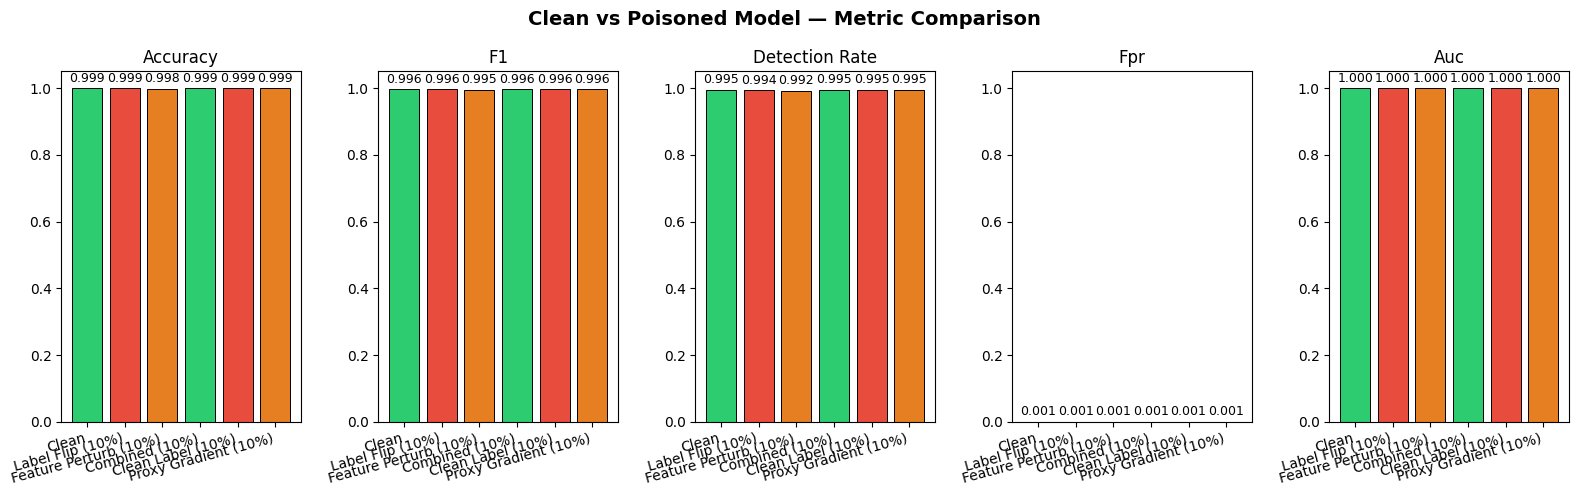

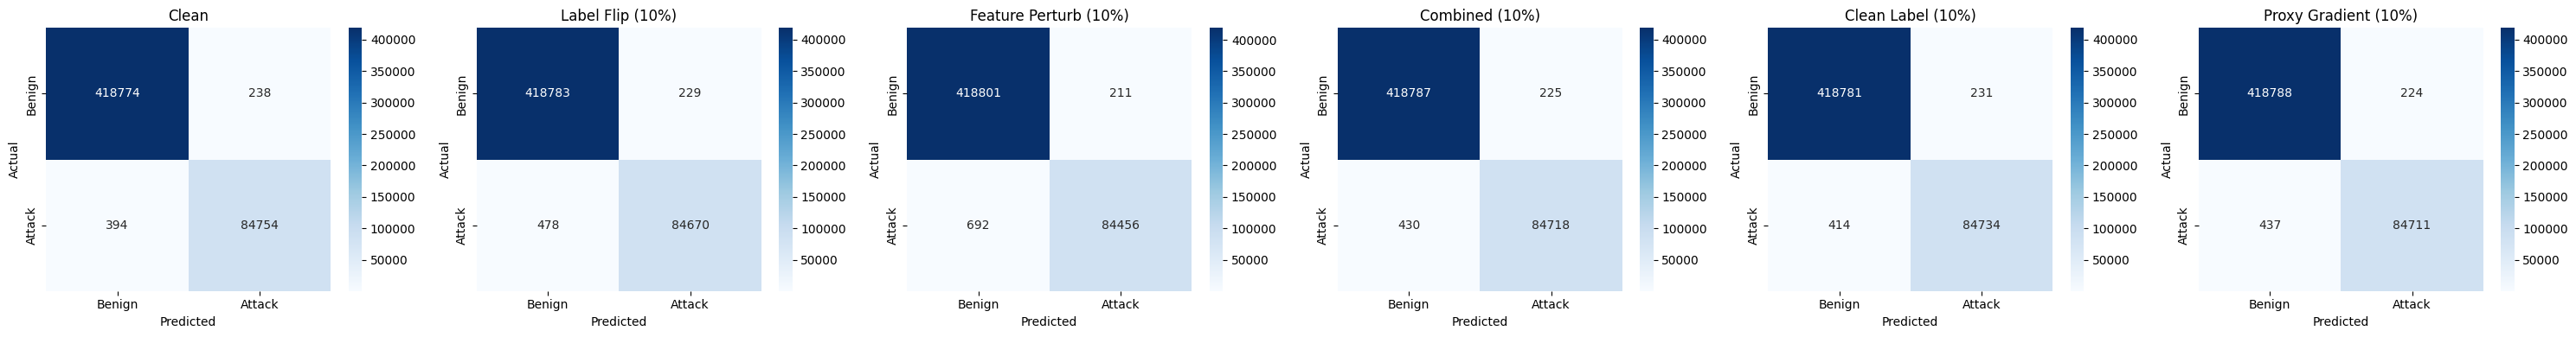

In [442]:
print("\n" + "="*75)
print("  ATTACK COMPARISON SUMMARY")
print("="*75)
print(f"{'Model':<25} {'Accuracy':>9} {'Detection':>10} {'F1':>8} {'AUC':>8}")
print("-"*75)
for r in all_results:
    print(f"  {r['label']:<23} "
          f"{r['accuracy']:>9.4f} "
          f"{r['detection_rate']:>10.4f} "
          f"{r['f1']:>8.4f} "
          f"{r['auc']:>8.4f}")
print("="*75)

# Only plot if we have results
if len(all_results) > 0:
    plot_comparison(all_results)

In [443]:
# if __name__ == "__main__":
#     ARTIFACT_DIR = "./artifacts"

#     # Load test set
#     X_test  = np.load(f"{ARTIFACT_DIR}/X_test.npy")
#     y_test  = np.load(f"{ARTIFACT_DIR}/y_test.npy")

#     # Define all attack variants to compare
#     variants = {
#         "Clean": (
#             f"{ARTIFACT_DIR}/X_train.npy",
#             f"{ARTIFACT_DIR}/y_train.npy"
#         ),
#         "Label Flip (10%)": (
#             f"{ARTIFACT_DIR}/X_train_label_flip.npy",
#             f"{ARTIFACT_DIR}/y_train_label_flip.npy"
#         ),
#         "Feature Perturb (10%)": (
#             f"{ARTIFACT_DIR}/X_train_feat_perturb.npy",
#             f"{ARTIFACT_DIR}/y_train_feat_perturb.npy"
#         ),
#         "Combined (10%)": (
#             f"{ARTIFACT_DIR}/X_train_combined.npy",
#             f"{ARTIFACT_DIR}/y_train_combined.npy"
#         ),
#         "Clean Label (10%)": (
#             f"{ARTIFACT_DIR}/X_train_clean_label.npy",
#             f"{ARTIFACT_DIR}/y_train_clean_label.npy"
#         ),
#         "Proxy Gradient (10%)": (                              # ← add this
#         f"{ARTIFACT_DIR}/X_train_proxy_gradient.npy",
#         f"{ARTIFACT_DIR}/y_train_proxy_gradient.npy"
#     ),
#     }

#     all_results = []
#     os.makedirs("models", exist_ok=True)

#     for name, (X_path, y_path) in variants.items():
#         print(f"\nTraining: {name}")
#         X_tr = np.load(X_path)
#         y_tr = np.load(y_path)

#         clf = train_rf(X_tr, y_tr, label=name)
#         joblib.dump(clf, f"models/rf_{name.replace(' ', '_').replace('%','pct')}.pkl")

#         result = evaluate(clf, X_test, y_test, label=name)
#         all_results.append(result)

#     # Print summary comparison table
#     print("\n" + "="*75)
#     print("  ATTACK COMPARISON SUMMARY")
#     print("="*75)
#     print(f"{'Model':<25} {'Accuracy':>9} {'Detection':>10} {'F1':>8} {'AUC':>8}")
#     print("-"*75)
#     for r in all_results:
#         print(f"  {r['label']:<23} "
#               f"{r['accuracy']:>9.4f} "
#               f"{r['detection_rate']:>10.4f} "
#               f"{r['f1']:>8.4f} "
#               f"{r['auc']:>8.4f}")
#     print("="*75)

#     plot_comparison(all_results)

##### Training Models

In [444]:
clf_clean    = train_rf(X_train,   y_train,   label="clean")


[Train] Random Forest — clean data ...
   Trained on 2,016,638 samples


In [445]:
ARTIFACT_DIR = "./artifacts"
X_train   = np.load(f"{ARTIFACT_DIR}/X_train.npy")
X_test    = np.load(f"{ARTIFACT_DIR}/X_test.npy")
y_train   = np.load(f"{ARTIFACT_DIR}/y_train.npy")
y_test    = np.load(f"{ARTIFACT_DIR}/y_test.npy")
X_train_p = np.load(f"{ARTIFACT_DIR}/X_train_poisoned.npy")
y_train_p = np.load(f"{ARTIFACT_DIR}/y_train_poisoned.npy")

FileNotFoundError: [Errno 2] No such file or directory: './artifacts/X_train_poisoned.npy'

In [ ]:
clf_poisoned = train_rf(X_train_p, y_train_p, label="poisoned (10%)")

NameError: name 'X_train_p' is not defined

In [ ]:
# Save models
os.makedirs("models", exist_ok=True)
joblib.dump(clf_clean,    "models/rf_clean.pkl")
joblib.dump(clf_poisoned, "models/rf_poisoned.pkl")
print("\n Models saved to ./models/")

# Evaluate on the SAME clean test set
r_clean    = evaluate(clf_clean,    X_test, y_test, "Clean Model")
r_poisoned = evaluate(clf_poisoned, X_test, y_test, "Poisoned Model (10%)")

# Visualise
plot_comparison([r_clean, r_poisoned])

NameError: name 'clf_poisoned' is not defined

In [ ]:
import numpy as np


ARTIFACT_DIR = "./artifacts"
X_train = np.load(f"{ARTIFACT_DIR}/X_train.npy")
y_train = np.load(f"{ARTIFACT_DIR}/y_train.npy")
X_test  = np.load(f"{ARTIFACT_DIR}/X_test.npy")
y_test  = np.load(f"{ARTIFACT_DIR}/y_test.npy")

print(f"{'Poison Rate':<15} {'Noise Std':<12} {'Detection Rate':<18} {'AUC'}")
print("-" * 60)

for poison_rate in [0.10, 0.20, 0.30, 0.50]:
    for noise_std in [0.05, 0.50, 2.00]:
        X_p, y_p, _ = combined_attack(
            X_train, y_train,
            poison_rate=poison_rate,
            noise_std=noise_std
        )
        clf = train_rf(X_p, y_p, label="")
        r = evaluate(clf, X_test, y_test, label="")
        print(f"  {poison_rate:<13.0%} {noise_std:<12.2f} "
              f"{r['detection_rate']:<18.4f} {r['auc']:.4f}")

Poison Rate     Noise Std    Detection Rate     AUC
------------------------------------------------------------

[Label Flip] poison_rate=10%
  Attack samples in train : 269,194
  Labels flipped          : 26,919
  New attack rate         : 0.1356  (was 0.1507)

[Combined Attack] Flipped labels AND perturbed features on 26,919 samples.

[Train] Random Forest —  data ...


KeyboardInterrupt: 

In [ ]:
# Flip ALL attack labels
y_extreme = y_train.copy()
attack_idx = np.where(y_train == 1)[0]
y_extreme[attack_idx] = 0

print(f"Original attack rate:  {y_train.mean():.4f}")
print(f"Poisoned attack rate:  {y_extreme.mean():.4f}  ← should be 0.0")
print(f"Unique classes in poisoned labels: {np.unique(y_extreme)}")

# Train
clf_extreme = train_rf(X_train, y_extreme, label="100% Poisoned")

# Manual evaluation — can't use normal evaluate because model only knows class 0
y_pred = clf_extreme.predict(X_test)

from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()

acc = (y_pred == y_test).mean()
dr  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

print(f"\n── 100% Poisoned Model ──")
print(f"  Accuracy       : {acc:.4f}")
print(f"  Detection Rate : {dr:.4f}  ← should be near 0.0")
print(f"  False Pos Rate : {fpr:.4f}")
print(f"  TP: {tp:,}  TN: {tn:,}  FP: {fp:,}  FN: {fn:,}")
print(f"\n  Unique predictions: {np.unique(y_pred)}")
print(f"  ← if only [0] appears, model predicts everything as benign")

Original attack rate:  0.1689
Poisoned attack rate:  0.0000  ← should be 0.0
Unique classes in poisoned labels: [0]

[Train] Random Forest — 100% Poisoned data ...
   Trained on 2,016,638 samples

── 100% Poisoned Model ──
  Accuracy       : 0.8311
  Detection Rate : 0.0000  ← should be near 0.0
  False Pos Rate : 0.0000
  TP: 0  TN: 419,012  FP: 0  FN: 85,148

  Unique predictions: [0]
  ← if only [0] appears, model predicts everything as benign
